# Para utilizarlo con collab

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')
# raiz="drive/MyDrive/proyecto_mineria/"
raiz=""

# Cargar datos y generar los conjuntos de entrenamiento y test

In [2]:
import pandas as pd
nombre_csv_logs="presentacion1_resultados"
# file_path = 'data_set_limpio.pkl'
file_path = f'{raiz}datasets_pkl/data_set_limpio_sin_not_for_sale.pkl'

df = pd.read_pickle(file_path)

# Display the loaded DataFrame
print("shape: ",df.shape)
print(df.columns)
df.sample(n=5)


shape:  (186795, 70)
Index(['Nat', 'Division', 'Club', 'Based', 'Preferred Foot', 'Right Foot',
       'Left Foot', 'Position', 'Height', 'Weight', 'Age', 'Wage', 'AT Apps',
       'AT Gls', 'Team', 'Caps', 'Yth Apps', 'Style', 'Rc Injury', 'Best Role',
       'Best Duty', 'Best Pos', 'Acc', 'Aer', 'Agg', 'Agi', 'Ant', 'Bal',
       'Bra', 'Cmd', 'Com', 'Cmp', 'Cnt', 'Cor', 'Cro', 'Dec', 'Det', 'Dri',
       'Ecc', 'Fin', 'Fir', 'Fla', 'Fre', 'Han', 'Hea', 'Jum', 'Kic', 'Ldr',
       'Lon', 'L Th', 'Mar', 'Nat .1', 'OtB', '1v1', 'Pac', 'Pas', 'Pen',
       'Pos', 'Pun', 'Ref', 'TRO', 'Sta', 'Str', 'Tck', 'Tea', 'Tec', 'Thr',
       'Vis', 'Wor', 'transfer_value_estimado'],
      dtype='object')


,Nat,Division,Club,Based,Preferred Foot,Right Foot,Left Foot,Position,Height,Weight,...,TRO,Sta,Str,Tck,Tea,Tec,Thr,Vis,Wor,transfer_value_estimado
72038,KOS,German Div. Baden-Württemberg,Reutlingen,Germany (Baden-Württemberg),Left Only,Very Weak,Very Strong,D (C),190,76,...,1,5,4,11,2,1,3,1,3,0
19559,BRA,-,-,Brazil,Right,Very Strong,Reasonable,"D (C), DM",184,78,...,2,12,10,13,11,10,3,7,11,0
45698,SVK,Slovak First Division,Trnava,Slovakia (First Division),Right Only,Very Strong,Weak,GK,196,78,...,13,11,14,10,9,7,10,2,2,88000
101467,ROU,-,-,Romania,Right Only,Very Strong,Weak,M (C),179,64,...,2,10,2,2,4,9,1,13,7,0
104005,ITA,Italian Serie B,Venezia,Italy (Serie B),Right Only,Very Strong,Weak,ST (C),184,71,...,2,5,6,1,4,11,1,4,5,37500


In [3]:
import pandas as pd
visualizar_todo=True
if visualizar_todo:
    # Show all rows
    pd.set_option('display.max_rows', None)

    # Show all columns
    pd.set_option('display.max_columns', None)

    # Show full content of each cell (prevent text truncation)
    pd.set_option('display.max_colwidth', None)


## Columnas del Dataframe

In [4]:
# df=df.drop(columns='Wage')
print(df.columns)

Index(['Nat', 'Division', 'Club', 'Based', 'Preferred Foot', 'Right Foot',
       'Left Foot', 'Position', 'Height', 'Weight', 'Age', 'Wage', 'AT Apps',
       'AT Gls', 'Team', 'Caps', 'Yth Apps', 'Style', 'Rc Injury', 'Best Role',
       'Best Duty', 'Best Pos', 'Acc', 'Aer', 'Agg', 'Agi', 'Ant', 'Bal',
       'Bra', 'Cmd', 'Com', 'Cmp', 'Cnt', 'Cor', 'Cro', 'Dec', 'Det', 'Dri',
       'Ecc', 'Fin', 'Fir', 'Fla', 'Fre', 'Han', 'Hea', 'Jum', 'Kic', 'Ldr',
       'Lon', 'L Th', 'Mar', 'Nat .1', 'OtB', '1v1', 'Pac', 'Pas', 'Pen',
       'Pos', 'Pun', 'Ref', 'TRO', 'Sta', 'Str', 'Tck', 'Tea', 'Tec', 'Thr',
       'Vis', 'Wor', 'transfer_value_estimado'],
      dtype='object')


# Generar conjuntos de entrenamiento y test

In [5]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [6]:
import clustering as cl

kmeans_model_club = cl.fit_kmeans(train_df, columna="Club")
kmeans_model_nat = cl.fit_kmeans(train_df, columna="Nat")
kmeans_model_division = cl.fit_kmeans(train_df, columna="Division")


train_df = cl.apply_kmeans(train_df, kmeans_model_club)
train_df = cl.apply_kmeans(train_df, kmeans_model_nat)
train_df = cl.apply_kmeans(train_df, kmeans_model_division)

test_df = cl.apply_kmeans(test_df, kmeans_model_club)
test_df = cl.apply_kmeans(test_df, kmeans_model_nat)
test_df = cl.apply_kmeans(test_df, kmeans_model_division)



In [7]:
target="transfer_value_estimado"
X_train = train_df.drop(columns=[target])
y_train = train_df[target]

X_test = test_df.drop(columns=[target])
y_test = test_df[target]

## One Hot para las features categóricas

In [8]:
import numpy as np
# categorical_cols=["Nat_cluster","Division_cluster","Club_cluster","Preferred Foot","Right Foot","Left Foot","Best Pos","Best Duty","Style","Best Role","Rc Injury"]
categorical_cols=["Nat_cluster","Division_cluster","Best Duty","Style"]
X_train = pd.get_dummies(X_train, columns=categorical_cols)
X_test  = pd.get_dummies(X_test, columns=categorical_cols)

X_train, X_test = X_train.align(X_test, join='left', axis=1,fill_value=0)

In [9]:
X_train = X_train.select_dtypes(include=[np.number,np.bool])
X_test = X_test.select_dtypes(include=[np.number,np.bool])

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

## Features finales

In [11]:
for col in X_train.columns:
    print(col)

Height
Weight
Age
Wage
AT Apps
AT Gls
Caps
Yth Apps
Acc
Aer
Agg
Agi
Ant
Bal
Bra
Cmd
Com
Cmp
Cnt
Cor
Cro
Dec
Det
Dri
Ecc
Fin
Fir
Fla
Fre
Han
Hea
Jum
Kic
Ldr
Lon
L Th
Mar
Nat .1
OtB
1v1
Pac
Pas
Pen
Pos
Pun
Ref
TRO
Sta
Str
Tck
Tea
Tec
Thr
Vis
Wor
Club_cluster
Nat_cluster_0
Nat_cluster_1
Nat_cluster_2
Nat_cluster_3
Nat_cluster_4
Division_cluster_0
Division_cluster_1
Division_cluster_2
Division_cluster_3
Division_cluster_4
Best Duty_Attack
Best Duty_Cover
Best Duty_Defend
Best Duty_Stopper
Best Duty_Support
Best Duty_Unknown
Style_Assertive
Style_Creative
Style_Distributor
Style_Intelligent
Style_Leader
Style_Physical
Style_Shot Stopper
Style_Technical


## Visualizar rangos de valores 
Para poder verificar que efectivamente se realizó la estandarización adecuadamente

In [12]:
X_train.sample(n=5)

,Height,Weight,Age,Wage,AT Apps,AT Gls,Caps,Yth Apps,Acc,Aer,Agg,Agi,Ant,Bal,Bra,Cmd,Com,Cmp,Cnt,Cor,Cro,Dec,Det,Dri,Ecc,Fin,Fir,Fla,Fre,Han,Hea,Jum,Kic,Ldr,Lon,L Th,Mar,Nat .1,OtB,1v1,Pac,Pas,Pen,Pos,Pun,Ref,TRO,Sta,Str,Tck,Tea,Tec,Thr,Vis,Wor,Club_cluster,Nat_cluster_0,Nat_cluster_1,Nat_cluster_2,Nat_cluster_3,Nat_cluster_4,Division_cluster_0,Division_cluster_1,Division_cluster_2,Division_cluster_3,Division_cluster_4,Best Duty_Attack,Best Duty_Cover,Best Duty_Defend,Best Duty_Stopper,Best Duty_Support,Best Duty_Unknown,Style_Assertive,Style_Creative,Style_Distributor,Style_Intelligent,Style_Leader,Style_Physical,Style_Shot Stopper,Style_Technical
83721,-0.616598,-0.222837,-1.053828,-0.137384,-0.570402,-0.433154,-0.144482,-0.191864,0.731268,-0.694605,-0.034400,1.374897,-1.072938,-1.705645,-0.727499,-0.752445,0.103142,-1.494114,-1.131140,0.170620,0.788496,-2.597493,0.606426,1.715564,0.229169,-0.408904,-0.068785,0.340635,0.109900,-0.351062,-1.201325,-1.141073,0.050680,-1.415213,-0.100506,-1.135719,-0.590639,-0.697045,-0.258883,0.095719,1.326489,0.038615,-0.847571,-0.737923,-0.721421,-0.672651,0.434178,0.601379,-1.008387,-0.641064,-0.483881,0.369283,-0.787268,0.732268,-0.485911,-0.956481,-0.005784,-2.218455,2.672844,-0.216402,-0.036332,-0.035586,-1.305613,-0.016566,1.318818,-0.05611,-0.559295,-0.19715,-0.782763,-0.166161,1.468147,-0.024548,-0.198829,-0.212596,-0.144248,-0.391496,-0.377658,-0.757423,-0.222118,1.834604
174403,0.085055,-0.358807,-1.053828,-0.116444,-0.711015,-0.433154,-0.144482,-0.191864,-0.151168,0.002512,0.290545,0.014358,0.425665,0.286537,0.167742,0.069661,0.103142,-0.054472,-0.402303,1.556367,1.075653,-0.199153,0.606426,0.951761,-0.846500,0.681964,0.227985,1.177477,2.086835,-0.014390,0.141450,-0.269898,-0.340771,0.527760,1.749496,0.825420,0.265530,-0.319680,0.869634,-0.332414,-0.050604,0.724800,-0.557857,0.249080,-0.335995,-0.352120,0.049088,0.303284,0.458022,0.594852,1.493808,0.658043,0.147307,1.050351,0.522051,1.063541,-0.005784,0.450764,-0.374133,-0.216402,-0.036332,-0.035586,0.765924,-0.016566,-0.758255,-0.05611,-0.559295,-0.19715,-0.782763,-0.166161,1.468147,-0.024548,-0.198829,-0.212596,-0.144248,-0.391496,2.647898,-0.757423,-0.222118,-0.545077
77802,0.786708,1.000897,0.565678,1.040491,0.634859,0.015852,-0.144482,-0.191864,-0.151168,-0.694605,-0.034400,-0.892668,0.800316,0.950598,1.062984,-0.341392,-0.776452,0.665349,1.055371,0.517056,-0.072973,-0.199153,0.364848,-0.066644,-0.846500,0.681964,-0.068785,0.061688,1.757345,-0.351062,1.215669,1.472451,0.050680,0.527760,1.132829,2.132846,1.692477,0.057685,-0.541012,-0.332414,0.867458,0.381708,0.890716,0.907082,0.049430,-0.352120,-0.721091,1.495664,1.631148,0.842035,1.823423,0.080522,-0.319980,-0.540064,1.194027,1.063541,-0.005784,0.450764,-0.374133,-0.216402,-0.036332,-0.035586,0.765924,-0.016566,-0.758255,-0.05611,-0.559295,-0.19715,1.277527,-0.166161,-0.681131,-0.024548,-0.198829,-0.212596,-0.144248,-0.391496,-0.377658,1.320266,-0.222118,-0.545077
5140,0.646378,0.864927,2.365129,-0.150471,2.924855,0.863973,-0.144482,-0.191864,-1.916039,0.351070,1.915274,-0.439155,1.924269,1.946690,1.958225,-0.341392,0.542939,1.025259,1.419790,-0.522254,0.501340,-0.199153,0.606426,-0.066644,-0.308665,0.409247,-0.068785,-1.333049,-0.878567,-0.687735,2.021334,0.891668,-0.732222,0.805328,-0.408840,2.786559,1.977866,-1.829140,0.023246,0.523853,-1.886728,0.381708,1.180430,1.894084,-0.335995,-0.031589,-0.336001,0.899474,1.631148,1.336401,1.493808,0.080522,-0.319980,0.732268,1.530014,-0.956481,-0.005784,0.450764,-0.374133,-0.216402,-0.036332,-0.035586,-1.305613,-0.016566,1.318818,-0.05611,-0.559295,-0.19715,-0.782763,6.018258,-0.681131,-0.024548,-0.198829,-0.212596,-0.144248,-0.391496,2.647898,-0.757423,-0.222118,-0.545077
64288,1.348031,1.136868,0.745623,-0.150471,-0.731103,-0.433154,-0.144482,-0.191864,0.731268,0.002512,0.290545,-0.439155,-0.323636,-1.041585,-1.921154,0.069661,-0.336655,-0.774293,-0.766721,-0.175817,0.501340,0.600294,-0.601467,-0.066644,0.767003,-0.681621,0.227985,

# Función para registrar en un csv resultados de diferentes regresiones

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import json
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def log_results(model, method_name, X_train, y_train, X_test, y_test, filepath=f"{raiz}{nombre_csv_logs}.csv"):
    # parameters
    params_dict = model.get_params()
    
    # Convert non-serializable objects
    for k, v in params_dict.items():
        try:
            json.dumps(v)
        except TypeError:
            params_dict[k] = str(v)

    params = json.dumps(params_dict)
    # Predictions
    y_pred = model.predict(X_test)
    
    # Metrics
    r2_train = model.score(X_train, y_train)
    r2_test = model.score(X_test, y_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    # Row to store
    row = {
        "method": method_name,
        "hyperparameters": json.dumps(params),
        "r2_train": r2_train,
        "r2_test": r2_test,
        "mae": mae,
        "rmse": rmse
    }
    
    #residuals
    # Plot 1: Residuals Distribution.
    residuals = y_test - y_pred
    plt.subplot(1,2,1)
    # plt.yscale('log')
    sns.histplot(residuals, bins=50, kde=True, color="blue")
    plt.axvline(x=0, color='red', linestyle='--')
    plt.title("Residuals Distribution")
    plt.xlabel("Residuals ")
    plt.ylabel("Frequency")


    # Plot 2: Regression Fit (Actual vs Predicted).
    plt.subplot(1,2,2)
    # plt.yscale('log')
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')  # Perfect fit line
    plt.title("Regression Fit: Actual vs Predicted")
    plt.xlabel("Actual Transfer Values")
    plt.ylabel("Predicted Transfer Values")


    # Show plots.
    plt.tight_layout()
    plt.show()
    
    # Append or create CSV
    try:
        df = pd.read_csv(filepath)
        df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    except FileNotFoundError:
        df = pd.DataFrame([row])
    
    df.to_csv(filepath, index=False)

# Mostrar relevancia de los coeficientes / variables

In [14]:
def sort_coeficients_graph(X,model):
    # Sort dataframe by coefficients.
    coef_df = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_})
    top_k = 20
    coef_df_sorted = coef_df.reindex(
        coef_df["Coefficient"].abs().sort_values(ascending=False).index
    ).head(top_k)

    # Create plot.
    # plt.figure(figsize=(8,6))
    plt.barh(coef_df_sorted["Feature"], coef_df_sorted["Coefficient"], color="blue")
    plt.xlabel("Coefficient Value")
    plt.ylabel("Feature")
    plt.title("Feature Importance (Linear Regression Coefficients)")
    plt.show()


In [15]:
X_train.shape

(149436, 80)

In [ ]:
row = df.loc[df['transfer_value_estimado'].idxmax()]
row

Height                -1.458581
Weight                -0.494778
Age                    0.565678
Wage                  45.891348
AT Apps                2.482926
AT Gls                 5.004803
Caps                  12.000556
Yth Apps               3.385021
Acc                    2.937356
Aer                   -0.694605
Agg                    0.615491
Agi                    3.188949
Ant                    3.422873
Bal                    1.946690
Bra                    0.764570
Cmd                   -0.341392
Com                   -0.336655
Cmp                    1.385169
Cnt                    1.784208
Cor                    0.863493
Cro                    1.937122
Dec                    1.000017
Det                    0.606426
Dri                    1.970166
Ecc                    0.767003
Fin                    1.772832
Fir                    1.118294
Fla                    1.735372
Fre                    1.427856
Han                   -0.014390
Hea                    1.215669
Jum     

In [17]:
print(row)

Height                -1.458581
Weight                -0.494778
Age                    0.565678
Wage                  45.891348
AT Apps                2.482926
AT Gls                 5.004803
Caps                  12.000556
Yth Apps               3.385021
Acc                    2.937356
Aer                   -0.694605
Agg                    0.615491
Agi                    3.188949
Ant                    3.422873
Bal                    1.946690
Bra                    0.764570
Cmd                   -0.341392
Com                   -0.336655
Cmp                    1.385169
Cnt                    1.784208
Cor                    0.863493
Cro                    1.937122
Dec                    1.000017
Det                    0.606426
Dri                    1.970166
Ecc                    0.767003
Fin                    1.772832
Fir                    1.118294
Fla                    1.735372
Fre                    1.427856
Han                   -0.014390
Hea                    1.215669
Jum     

# REGRESIONES

In [18]:
RS=0

## LinearRegression

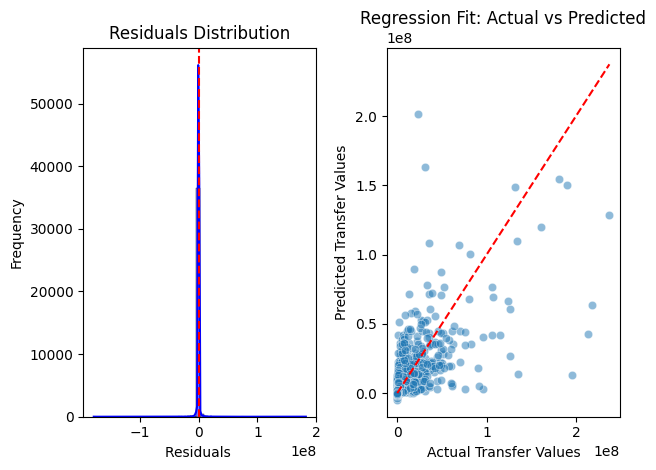

/var/folders/fp/3x23p7jn0494g8g5z6bcvmzw0000gn/T/ipykernel_48591/653267599.py:67: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)


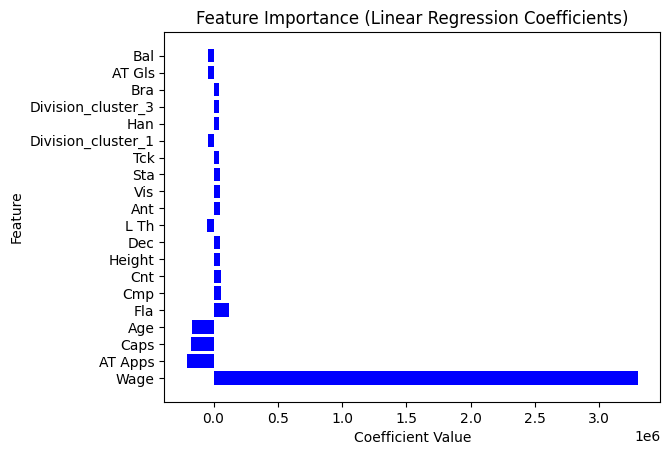

In [19]:
from sklearn.linear_model import LinearRegression
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)

log_results(linear_reg,"LinearRegression",X_train,y_train,X_test,y_test)
sort_coeficients_graph(X_train,linear_reg)


## Ridge

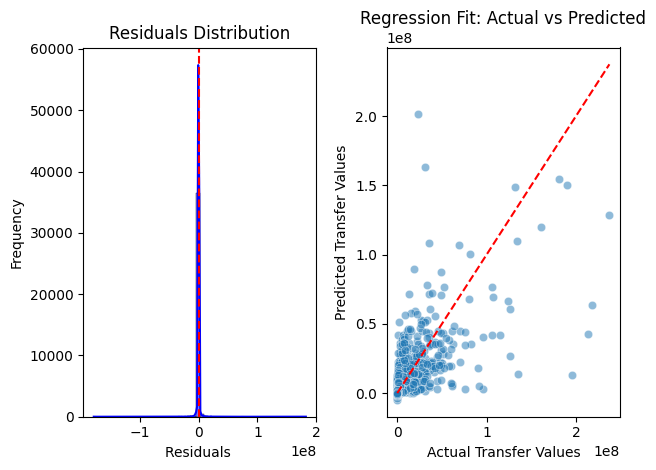

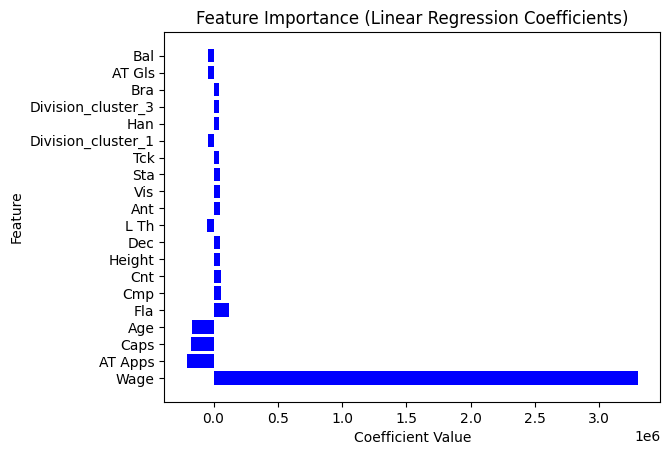

In [20]:
from sklearn.linear_model import RidgeCV
ridge_reg = RidgeCV()
ridge_reg.fit(X_train, y_train)

log_results(ridge_reg,"RidgeCV",X_train,y_train,X_test,y_test)
sort_coeficients_graph(X_train,ridge_reg)

## Lasso

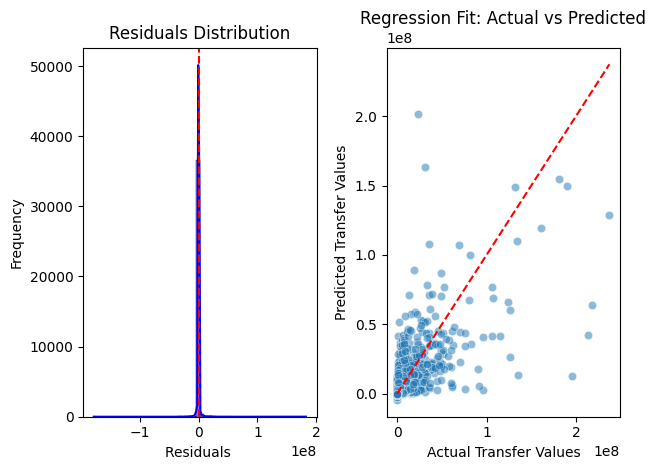

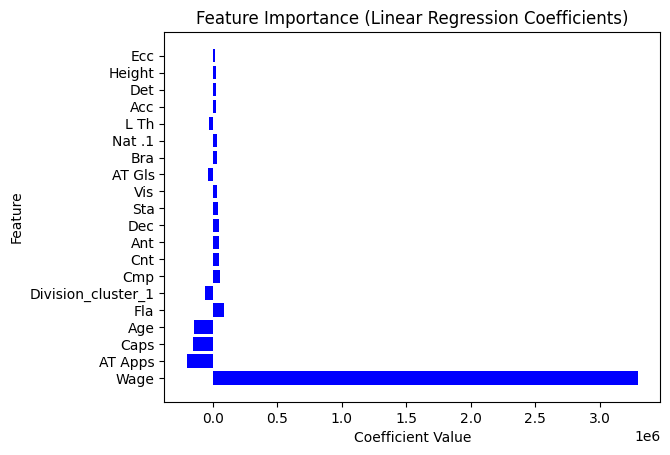

In [21]:
from sklearn.linear_model import LassoCV
lasso_reg = LassoCV(random_state=RS)
lasso_reg.fit(X_train, y_train)

log_results(lasso_reg,"LassoCV",X_train,y_train,X_test,y_test)
sort_coeficients_graph(X_train,lasso_reg)

## ElasticNet

In [ ]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV

param_grid = {
    "alpha": [0.01, 0.1, 1, 10],
    "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

grid = GridSearchCV(ElasticNet(max_iter=10000), param_grid, cv=5)
grid.fit(X_train, y_train)

elastic_net_reg_grid=grid.best_estimator_
log_results(elastic_net_reg_grid,"ElasticNetCV_grid",X_train,y_train,X_test,y_test)
sort_coeficients_graph(X_train,elastic_net_reg_grid)

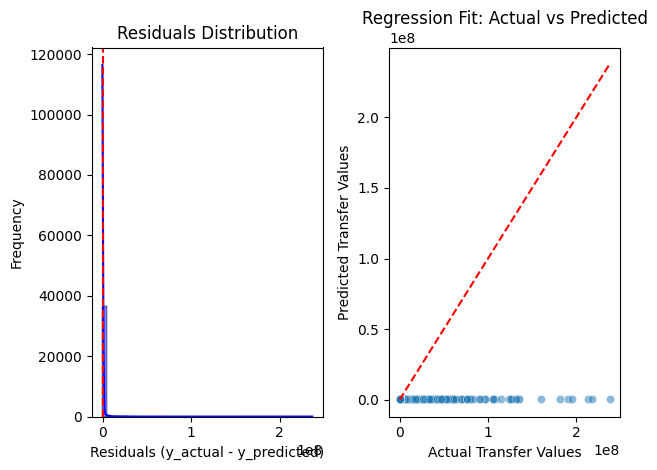

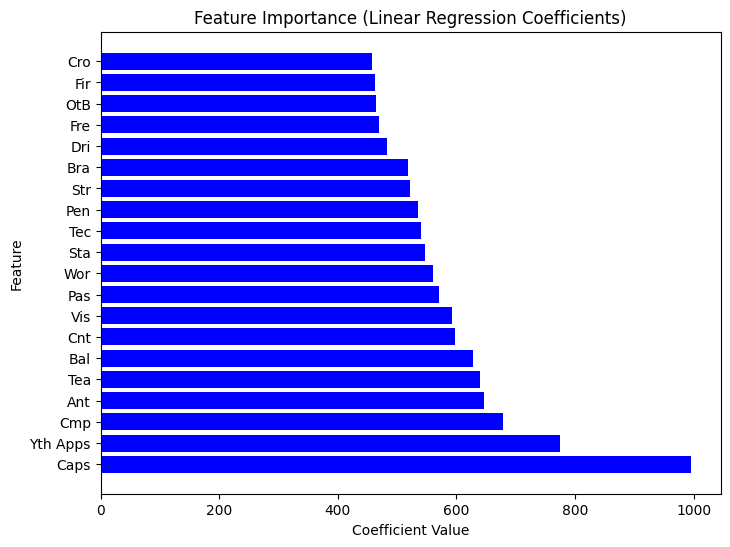

In [ ]:
from sklearn.linear_model import ElasticNetCV
elastic_net_reg = ElasticNetCV(random_state=RS)
elastic_net_reg.fit(X_train, y_train)

log_results(elastic_net_reg,"ElasticNetCV",X_train,y_train,X_test,y_test)
sort_coeficients_graph(X_train,elastic_net_reg)


## MLPRegressor

In [ ]:
# from sklearn.neural_network import MLPRegressor

# # random_state=RS,learning_rate_init=0.5,learning_rate="adaptive", max_iter=1000, tol=1e-4,verbose=False
# mlp_reg = MLPRegressor(random_state=RS,learning_rate_init=0.001,learning_rate="adaptive", max_iter=500, tol=1e-4,verbose=False)

# mlp_reg.fit(X_train, y_train)
# log_results(mlp_reg,"MLPRegressor",X_train,y_train,X_test,y_test)

# sort_coeficients_graph(X_train,elastic_net_reg)